In [1]:
import polars as pl

df = pl.read_parquet(
    "datasets/megascale_dataset_with_ddg.parquet",
)
df

original_seq_full,mutated_seq_full,deltaG,deltaG_wt,ddG,mut_type
str,str,f64,f64,f64,str
"""SAGGSEPSQADLDALLSAVRDNRLSIEQAV…","""SAGGSEPSQADLDALLLAVRDNRLSIEQAV…",3.496347,3.478886,0.017461,"""S17L"""
"""SAGGSQIFVKTLTGKTITLEVEPSDTIENV…","""SAGGSQIFVKTLTGKDITLEVEPSDTIENV…",3.649809,5.144088,-1.494279,"""T16D"""
"""SAGGSAGGSAGGWEITFERNGKRITVRTTD…","""SAGGSAGGSAGGWEITFERNGKRITVRTTD…",3.240064,3.924536,-0.684472,"""L36D"""
"""SAGGSAGGSAGGSTVKVRLGHLEVTLHNVS…","""SAGGSAGGSAGGSTVKVRLGHLEVTLHNVS…",4.027525,4.091532,-0.064007,"""E55K"""
"""SAGGSAGGSAGGSVLKALERTRQLDIPDEK…","""SAGGSAGGSAGGSVLKALERTRQLDIPDEK…",-0.270955,2.753485,-3.024441,"""L39G"""
…,…,…,…,…,…
"""SAGGSAVTTYKLVINGKTLKGETTTKAVDA…","""SAGGSAVTTYKLVLNGKTLKGETTTKAVDA…",2.028986,2.787899,-0.758913,"""I14L"""
"""SAGGNKASVVANQLIPINTALTLIMMKAEV…","""SAGGNKASVVANQLIPINTALTLIMMKAEV…",4.873974,5.143278,-0.269304,"""P54H"""
"""SAGGSAGGSAGGSAGGQTQEFDNEEEARKA…","""SAGGSAGGSAGGSAGGQTQEFIREEEARKA…",1.83027,3.130953,-1.300683,"""D22I:N23R"""


In [2]:
df.select(pl.col("ddG")).describe()

statistic,ddG
str,f64
"""count""",416914.0
"""null_count""",0.0
"""mean""",-1.51392
"""std""",1.939565
"""min""",-17.674774
"""25%""",-2.245559
"""50%""",-0.92614
"""75%""",-0.177381
"""max""",8.677801


In [12]:
k_neg = 0.230
k_pos = 0.576
A_neg = 1.0
A_pos = 1.0

sigmoid_expr = (
    pl.when(pl.col("ddG") >= 0)
    .then(A_pos * (2 / (1 + (-k_pos * pl.col("ddG")).exp()) - 1))
    .otherwise(-A_neg * (2 / (1 + (-k_neg * (-pl.col("ddG"))).exp()) - 1))
)

df = df.with_columns(
    sigmoid_expr.alias("normalized_ddG_sigmoid")
)

df = df.with_columns(
    (pl.col("normalized_ddG_sigmoid")) .alias("normalized_stability")
)

## add reverse mutations

# reverse mutation
df_joined = df.with_columns(pl.lit(False).alias("reverse"))

# Reverzní mutace
df_joined_with_reverse = df_joined.with_columns([
    pl.col("original_seq_full").alias("mutated_seq_full"),
    pl.col("mutated_seq_full").alias("original_seq_full"),
    # multiply by -1
    pl.col("normalized_stability") * -1,

    pl.lit(True).alias("reverse")
])




df_joined_with_reverse = pl.concat([df_joined, df_joined_with_reverse])

df_joined_with_reverse = df_joined_with_reverse.select([pl.col("original_seq_full"),
                                                       pl.col("mutated_seq_full"),
                                                       pl.col("deltaG"),
                                                       pl.col("deltaG_wt"),
                                                       pl.col("ddG"),
                                                       pl.col("mut_type"),
                                                           pl.col("normalized_stability"),
                                                       pl.col("reverse")])



df_joined_with_reverse.write_csv("datasets/megascale_dataset_with_ddg_normalized.csv")
df_joined_with_reverse

original_seq_full,mutated_seq_full,deltaG,deltaG_wt,ddG,mut_type,normalized_stability,reverse
str,str,f64,f64,f64,str,f64,bool
"""SAGGSEPSQADLDALLSAVRDNRLSIEQAV…","""SAGGSEPSQADLDALLLAVRDNRLSIEQAV…",3.496347,3.478886,0.017461,"""S17L""",0.005029,false
"""SAGGSQIFVKTLTGKTITLEVEPSDTIENV…","""SAGGSQIFVKTLTGKDITLEVEPSDTIENV…",3.649809,5.144088,-1.494279,"""T16D""",-0.17017,false
"""SAGGSAGGSAGGWEITFERNGKRITVRTTD…","""SAGGSAGGSAGGWEITFERNGKRITVRTTD…",3.240064,3.924536,-0.684472,"""L36D""",-0.078552,false
"""SAGGSAGGSAGGSTVKVRLGHLEVTLHNVS…","""SAGGSAGGSAGGSTVKVRLGHLEVTLHNVS…",4.027525,4.091532,-0.064007,"""E55K""",-0.007361,false
"""SAGGSAGGSAGGSVLKALERTRQLDIPDEK…","""SAGGSAGGSAGGSVLKALERTRQLDIPDEK…",-0.270955,2.753485,-3.024441,"""L39G""",-0.334433,false
…,…,…,…,…,…,…,…
"""SAGGSAVTTYKLVLNGKTLKGETTTKAVDA…","""SAGGSAVTTYKLVINGKTLKGETTTKAVDA…",2.028986,2.787899,-0.758913,"""I14L""",0.087054,true
"""SAGGNKASVVANQLIPINTALTLIMMKAEV…","""SAGGNKASVVANQLIPINTALTLIMMKAEV…",4.873974,5.143278,-0.269304,"""P54H""",0.03096,true
"""SAGGSAGGSAGGSAGGQTQEFIREEEARKA…","""SAGGSAGGSAGGSAGGQTQEFDNEEEARKA…",1.83027,3.130953,-1.300683,"""D22I:N23R""",0.148473,true


In [13]:
df["normalized_stability"].describe()

statistic,value
str,f64
"""count""",416914.0
"""null_count""",0.0
"""mean""",-0.151919
"""std""",0.202927
"""min""",-0.96626
"""25%""",-0.252648
"""50%""",-0.106105
"""75%""",-0.020396
"""max""",0.986593


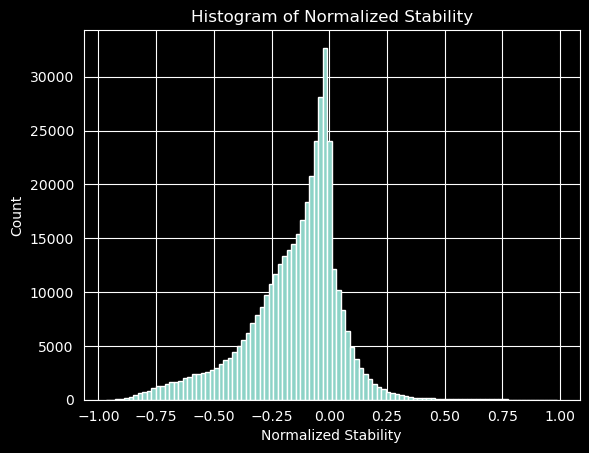

In [16]:
# create histogram of normalized_stability
import matplotlib.pyplot as plt
plt.hist(df_joined_with_reverse.filter(pl.col("reverse") == False).select("normalized_stability"), bins=100)
plt.xlabel("Normalized Stability")
plt.ylabel("Count")
plt.title("Histogram of Normalized Stability")
plt.show()

In [6]:
len(unique_seqs_lehner)

NameError: name 'unique_seqs_lehner' is not defined